In [1]:
import pybaseball as pyb
import pandas as pd

pyb.cache.enable()

In [2]:
df = pyb.statcast(start_dt='2025-03-27', end_dt='2025-09-28')
print(df.shape)

This is a large query, it may take a moment to complete


100%|██████████████████████████████| 186/186 [01:24<00:00,  2.19it/s]


(711897, 118)


In [3]:
df.to_parquet('statcast_2025_full.parquet')
print("Saved!")

Saved!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('statcast_2025_full.parquet')
print(f"Shape: {df.shape}")
print(f"Date range: {df['game_date'].min()} to {df['game_date'].max()}")

Shape: (711897, 118)
Date range: 2025-03-27 to 2025-09-28


In [5]:
swings = df[df['bat_speed'].notna()].copy()

def count_state(strikes):
    if strikes == 2:
        return '2-strike'
    elif strikes == 1:
        return '1-strike'
    else:
        return '0-strike'

swings['count_state'] = swings['strikes'].apply(count_state)
print(f"Total swings: {len(swings):,}")
print(swings['count_state'].value_counts())

Total swings: 328,975
count_state
2-strike    123557
1-strike    110419
0-strike     94999
Name: count, dtype: int64


In [6]:
print(f"Before hygiene: {len(swings):,} swings")

# Filter out clearly artifactual bat speed values
swings = swings[(swings['bat_speed'] >= 40) & (swings['bat_speed'] <= 95)]

# Filter clearly bad swing length values
swings = swings[(swings['swing_length'] >= 4) & (swings['swing_length'] <= 11)]

# Drop rows missing either core metric
swings = swings.dropna(subset=['bat_speed', 'swing_length'])

print(f"After hygiene: {len(swings):,} swings")

Before hygiene: 328,975 swings
After hygiene: 321,479 swings


In [7]:
print("BAT SPEED by count state:")
print(swings.groupby('count_state')['bat_speed'].agg(['count', 'mean', 'median', 'std']).round(2))
print()
print("SWING LENGTH by count state:")
print(swings.groupby('count_state')['swing_length'].agg(['count', 'mean', 'median', 'std']).round(2))

BAT SPEED by count state:
              count   mean  median   std
count_state                             
0-strike      91995  71.92    72.5  5.95
1-strike     107980  71.06    71.7  6.11
2-strike     121504  69.37    70.1  6.39

SWING LENGTH by count state:
              count  mean  median   std
count_state                            
0-strike      91995  7.34     7.3  0.86
1-strike     107980  7.27     7.3  0.89
2-strike     121504  7.18     7.2  0.93


In [8]:
# For each hitter, compute mean bat speed and swing length in each count state
hitter_stats = swings.groupby(['batter', 'count_state']).agg(
    bat_speed=('bat_speed', 'mean'),
    swing_length=('swing_length', 'mean'),
    n_swings=('bat_speed', 'count')
).reset_index()

# Pivot so each hitter is one row with columns for each count state
pivot_bs = hitter_stats.pivot(index='batter', columns='count_state', values='bat_speed')
pivot_sl = hitter_stats.pivot(index='batter', columns='count_state', values='swing_length')
pivot_n  = hitter_stats.pivot(index='batter', columns='count_state', values='n_swings')

# Build the per-hitter dataframe
hitters = pd.DataFrame({
    'bat_speed_0s': pivot_bs['0-strike'],
    'bat_speed_2s': pivot_bs['2-strike'],
    'swing_length_0s': pivot_sl['0-strike'],
    'swing_length_2s': pivot_sl['2-strike'],
    'swings_0s': pivot_n['0-strike'],
    'swings_2s': pivot_n['2-strike'],
})

# Compute the adjustment: how much they slowed down with two strikes
hitters['bat_speed_adj'] = hitters['bat_speed_0s'] - hitters['bat_speed_2s']
hitters['swing_length_adj'] = hitters['swing_length_0s'] - hitters['swing_length_2s']

# Filter to qualified hitters — at least 100 swings in each count state
qualified = hitters[(hitters['swings_0s'] >= 100) & (hitters['swings_2s'] >= 100)].copy()

print(f"Qualified hitters: {len(qualified)}")
print(f"League-wide mean bat speed adjustment: {qualified['bat_speed_adj'].mean():.2f} mph")
print(f"League-wide mean swing length adjustment: {qualified['swing_length_adj'].mean():.2f} ft")

Qualified hitters: 342
League-wide mean bat speed adjustment: 2.38 mph
League-wide mean swing length adjustment: 0.13 ft


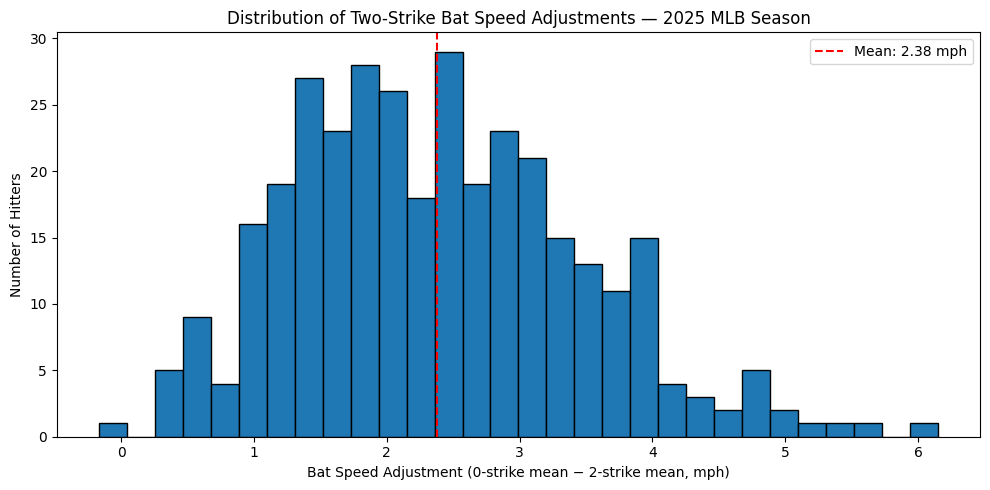

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(qualified['bat_speed_adj'], bins=30, edgecolor='black')
ax.axvline(qualified['bat_speed_adj'].mean(), color='red', linestyle='--', label=f'Mean: {qualified["bat_speed_adj"].mean():.2f} mph')
ax.set_xlabel('Bat Speed Adjustment (0-strike mean − 2-strike mean, mph)')
ax.set_ylabel('Number of Hitters')
ax.set_title('Distribution of Two-Strike Bat Speed Adjustments — 2025 MLB Season')
ax.legend()
plt.tight_layout()
plt.savefig('league_adjustment_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
ids = qualified.index.tolist()
names = pyb.playerid_reverse_lookup(ids)
names['name'] = names['name_first'].str.title() + ' ' + names['name_last'].str.title()

# Drop name column if a prior run already added it
qualified = qualified.drop(columns=['name'], errors='ignore')

qualified = qualified.merge(
    names[['key_mlbam', 'name']],
    left_index=True,
    right_on='key_mlbam',
    how='left'
).set_index('key_mlbam')

print(f"Hitters matched: {qualified['name'].notna().sum()} / {len(qualified)}")

Hitters matched: 342 / 342


In [15]:
print("=== TOP 10 BAT SPEED ADJUSTERS (slow down most with 2 strikes) ===")
print(qualified.nlargest(10, 'bat_speed_adj')[['name', 'bat_speed_0s', 'bat_speed_2s', 'bat_speed_adj', 'swings_2s']].round(2))
print()
print("=== BOTTOM 10 BAT SPEED ADJUSTERS (slow down least or speed up) ===")
print(qualified.nsmallest(10, 'bat_speed_adj')[['name', 'bat_speed_0s', 'bat_speed_2s', 'bat_speed_adj', 'swings_2s']].round(2))

=== TOP 10 BAT SPEED ADJUSTERS (slow down most with 2 strikes) ===
                     name  bat_speed_0s  bat_speed_2s  bat_speed_adj  \
key_mlbam                                                              
691019          Kyle Teel         71.26         65.11           6.15   
516782     Starling Marte         73.55         68.02           5.53   
666185      Dylan Carlson          70.8         65.31           5.49   
670623      Isaac Paredes         71.01         65.76           5.25   
660271      Shohei Ohtani         76.58         71.59            5.0   
665926     Andrés Giménez         70.52         65.62            4.9   
647351       Abraham Toro         70.96         66.07           4.89   
624641       Edmundo Sosa         73.39         68.52           4.87   
681082       Bryson Stott         71.41         66.58           4.83   
676609     José Caballero         70.46         65.63           4.83   

           swings_2s  
key_mlbam             
691019           207  

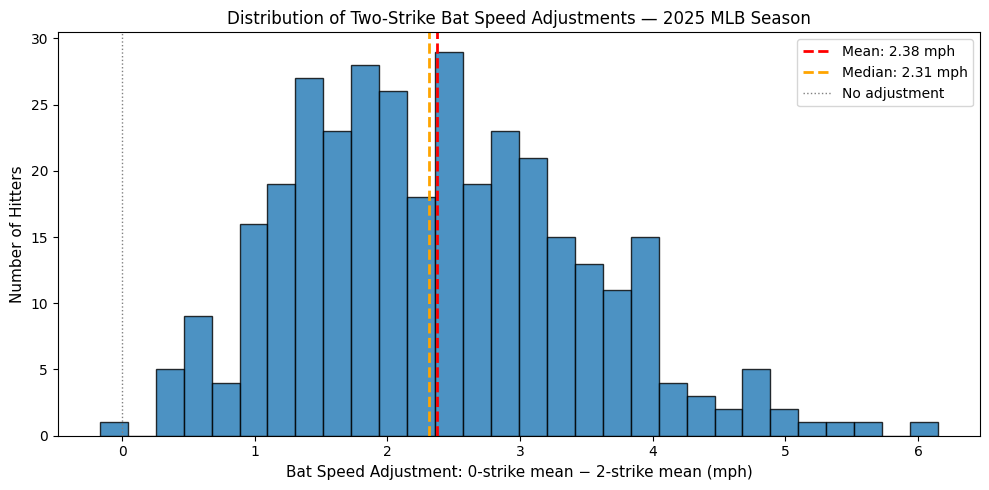

Hitters with negative adjustment (faster with 2 strikes): 1
Hitters adjusting more than 3 mph: 94
Range: -0.17 to 6.15 mph


In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(qualified['bat_speed_adj'], bins=30, edgecolor='black', alpha=0.8)

mean_adj = qualified['bat_speed_adj'].mean()
median_adj = qualified['bat_speed_adj'].median()

ax.axvline(mean_adj, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_adj:.2f} mph')
ax.axvline(median_adj, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_adj:.2f} mph')
ax.axvline(0, color='gray', linestyle=':', linewidth=1, label='No adjustment')

ax.set_xlabel('Bat Speed Adjustment: 0-strike mean − 2-strike mean (mph)', fontsize=11)
ax.set_ylabel('Number of Hitters', fontsize=11)
ax.set_title('Distribution of Two-Strike Bat Speed Adjustments — 2025 MLB Season', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('league_adjustment_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Hitters with negative adjustment (faster with 2 strikes): {(qualified['bat_speed_adj'] < 0).sum()}")
print(f"Hitters adjusting more than 3 mph: {(qualified['bat_speed_adj'] > 3).sum()}")
print(f"Range: {qualified['bat_speed_adj'].min():.2f} to {qualified['bat_speed_adj'].max():.2f} mph")